# Lab 8: Play Tennis Classification

This notebook implements **Categorical Naive Bayes** for the Play Tennis dataset and compares it with Decision Tree and Logistic Regression.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style='whitegrid', palette='deep')
warnings.filterwarnings('ignore')   

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


Dataset shape: (50, 5)

Class distribution:


,Count
Play Tennis,
Yes,34
No,16


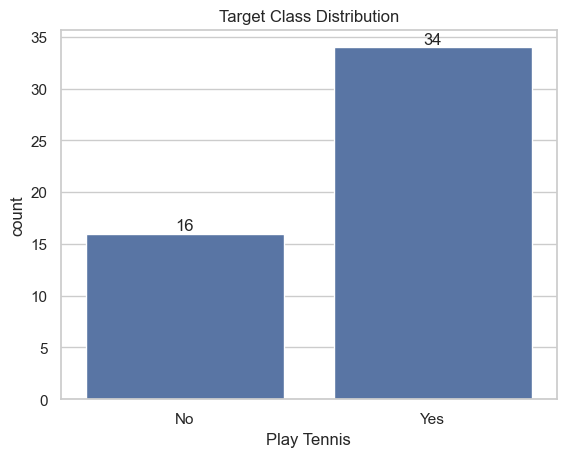

In [2]:
# Load the supplied dataset
df = pd.read_excel('Lab 8.xlsx')
df = df.drop(columns='No')  # serial number is not a predictive feature
display(df.head())
print(f'Dataset shape: {df.shape}')
print('\nClass distribution:')
display(df['Play Tennis'].value_counts().rename_axis('Play Tennis').to_frame('Count'))

ax = sns.countplot(data=df, x='Play Tennis', order=['No', 'Yes'])
ax.set_title('Target Class Distribution')
ax.set_xlabel('Play Tennis')
ax.bar_label(ax.containers[0])
plt.show()

In [3]:
# Separate input features and target
feature_cols = ['Outlook', 'Temperature', 'Humidity', 'Wind']
X = df[feature_cols]
y = df['Play Tennis']

# Stratification keeps the Yes/No ratio comparable in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows')
display(pd.DataFrame({'Feature': feature_cols, 'Data type': X.dtypes.astype(str).values}))

Training set: 40 rows | Test set: 10 rows


,Feature,Data type
0,Outlook,object
1,Temperature,object
2,Humidity,object
3,Wind,object


In [4]:
# CategoricalNB requires each categorical feature to be represented by non-negative integers.
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded = ordinal_encoder.fit_transform(X_train).astype(int)
X_test_encoded = ordinal_encoder.transform(X_test).astype(int)

encoding_table = pd.DataFrame({
    'Feature': feature_cols,
    'Categories (encoded in alphabetical order)': [', '.join(cats) for cats in ordinal_encoder.categories_]
})
display(encoding_table)
display(pd.DataFrame(X_train_encoded, columns=feature_cols, index=X_train.index).head())

,Feature,Categories (encoded in alphabetical order)
0,Outlook,"Overcast, Rain, Sunny"
1,Temperature,"Cool, Hot, Mild"
2,Humidity,"High, Normal"
3,Wind,"Strong, Weak"


,Outlook,Temperature,Humidity,Wind
14,2,0,0,1
0,2,1,0,1
2,0,1,0,1
21,0,2,1,0
29,2,2,0,0


Categorical Naive Bayes accuracy: 90.00%

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.67      0.80         3
         Yes       0.88      1.00      0.93         7

    accuracy                           0.90        10
   macro avg       0.94      0.83      0.87        10
weighted avg       0.91      0.90      0.89        10



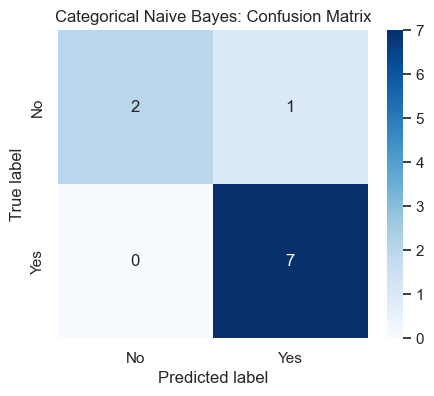

In [5]:
# Train and evaluate Categorical Naive Bayes
cnb = CategoricalNB(alpha=1.0)
cnb.fit(X_train_encoded, y_train)
cnb_pred = cnb.predict(X_test_encoded)
cnb_accuracy = accuracy_score(y_test, cnb_pred)

print(f'Categorical Naive Bayes accuracy: {cnb_accuracy:.2%}')
print('\nClassification Report:')
print(classification_report(y_test, cnb_pred, labels=['No', 'Yes'], zero_division=0))

cm = confusion_matrix(y_test, cnb_pred, labels=['No', 'Yes'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Categorical Naive Bayes: Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

In [6]:
# Predict a new weather condition
new_weather = pd.DataFrame([['Sunny', 'Cool', 'High', 'Strong']], columns=feature_cols)
new_weather_encoded = ordinal_encoder.transform(new_weather).astype(int)
predicted_class = cnb.predict(new_weather_encoded)[0]
probabilities = cnb.predict_proba(new_weather_encoded)[0]

print('Weather condition: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong')
print(f'Predicted class: {predicted_class}')
probability_df = pd.DataFrame({'Class': cnb.classes_, 'Probability': probabilities})
probability_df['Probability'] = probability_df['Probability'].map(lambda p: f'{p:.2%}')
display(probability_df)

Weather condition: Outlook=Sunny, Temperature=Cool, Humidity=High, Wind=Strong
Predicted class: No


,Class,Probability
0,No,78.94%
1,Yes,21.06%


,Model,Accuracy
0,Categorical Naive Bayes,90.00%
1,Decision Tree,90.00%
2,Logistic Regression,90.00%


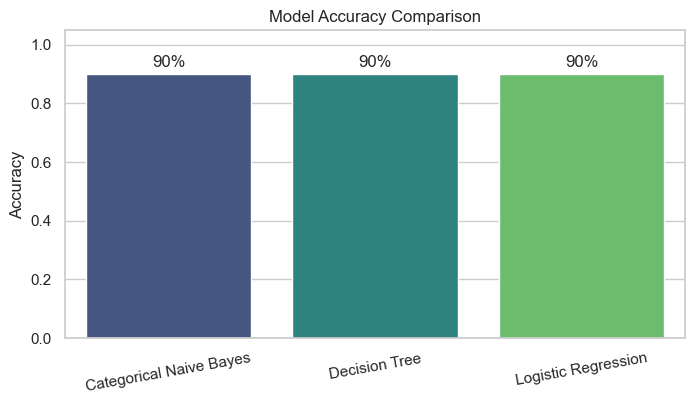

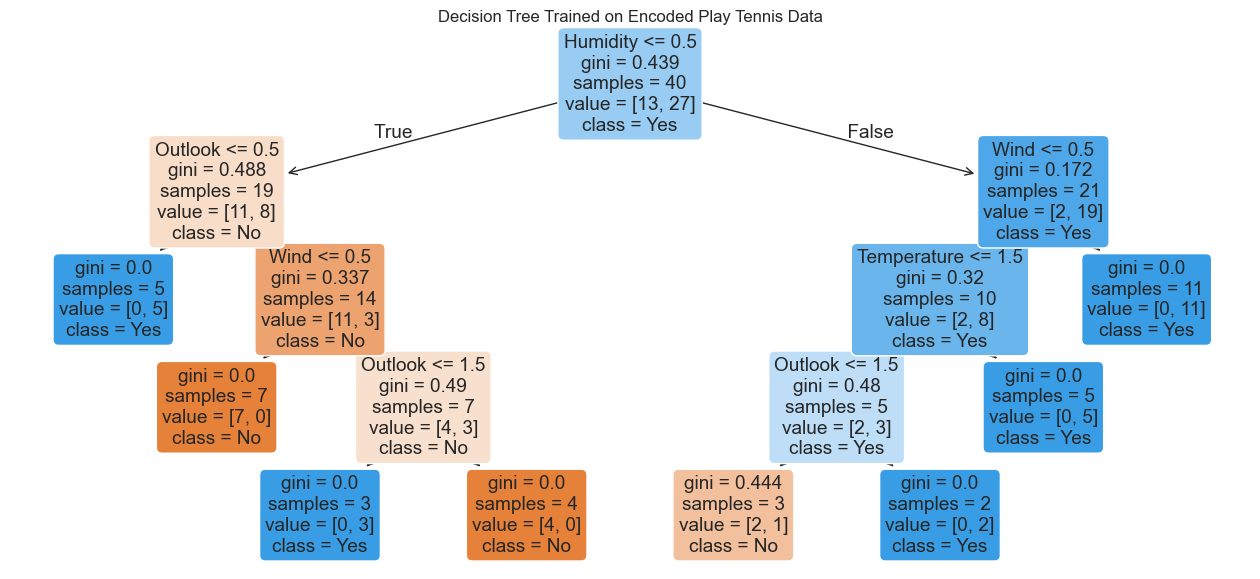

In [7]:
# Compare CategoricalNB with Decision Tree and Logistic Regression
decision_tree = DecisionTreeClassifier(random_state=42, max_depth=4)
decision_tree.fit(X_train_encoded, y_train)
dt_pred = decision_tree.predict(X_test_encoded)

# One-hot encoding prevents Logistic Regression from interpreting category codes as ordered values.
logistic_model = Pipeline([
    ('encoder', ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore'), feature_cols)])),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
logistic_model.fit(X_train, y_train)
lr_pred = logistic_model.predict(X_test)

results = pd.DataFrame({
    'Model': ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [cnb_accuracy, accuracy_score(y_test, dt_pred), accuracy_score(y_test, lr_pred)]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(results.style.format({'Accuracy': '{:.2%}'}))

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=results, x='Model', y='Accuracy', hue='Model', legend=False, palette='viridis')
ax.set_ylim(0, 1.05)
ax.set_title('Model Accuracy Comparison')
ax.set_xlabel('')
ax.set_ylabel('Accuracy')
for bar, accuracy in zip(ax.patches, results['Accuracy']):
    ax.annotate(f'{accuracy:.0%}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')
plt.xticks(rotation=10)
plt.show()

plt.figure(figsize=(16, 7))
plot_tree(decision_tree, feature_names=feature_cols, class_names=decision_tree.classes_, filled=True, rounded=True)
plt.title('Decision Tree Trained on Encoded Play Tennis Data')
plt.show()

## Conclusion

The comparison table and chart show the test-set accuracy for all three models. Categorical Naive Bayes is especially appropriate here because every predictor is categorical; Logistic Regression uses one-hot encoding so that its input categories have no artificial numeric ordering.